# FL HeVerSa QAT Result Analysis

Compare loss and accuracy curves for `fedavg_qat_plain` vs `fedavg_qat_heversa` across CIFAR-10, MNIST, and OrganAMNIST for CNN and MLP runs.

## Settings

Set `FILE_PREFIX` when your output files were created with `--output-prefix`. For example, use `"trial1"` for files named like `trial1_mnist_cnn_rep0_...json`. Leave it empty to include every prefix.

In [6]:
from pathlib import Path
from collections import defaultdict
import json
import re
import statistics

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "matplotlib is required for plotting. Install it in this notebook kernel "
        "or switch to a Python environment that already has matplotlib."
    ) from exc

# Change this if your fl_heversa outputs were created with --output-prefix.
# Examples: "trial1", "trial2". Leave as "" to include every prefix.
FILE_PREFIX = ""

# Keep True when FILE_PREFIX should match only files that start with that prefix.
FILTER_BY_PREFIX = bool(FILE_PREFIX)

# Auto-detect whether the notebook is run from the repo root or from fl/.
RESULTS_DIR = Path("fl/results") if Path("fl/results").exists() else Path("results")

DATASETS = ["cifar10", "mnist", "organamnist"]
NETWORKS = ["cnn", "mlp"]

DISPLAY_NAMES = {
    "cifar10": "CIFAR-10",
    "mnist": "MNIST",
    "organamnist": "OrganAMNIST",
}

SERIES = {
    "fedavg_qat_plain": "QAT plain",
    "fedavg_qat_heversa": "QAT HeVerSa",
}

SERIES_ORDER = ["QAT plain", "QAT HeVerSa"]
COLORS = {"QAT plain": "tab:blue", "QAT HeVerSa": "tab:orange"}

print(f"Reading results from: {RESULTS_DIR.resolve()}")
print(f"FILE_PREFIX filter: {FILE_PREFIX!r}" if FILTER_BY_PREFIX else "FILE_PREFIX filter: disabled")

Reading results from: /lustre/home/frroccod/verifiable_sec_agg/fl/results
FILE_PREFIX filter: disabled


## Load Result Files

In [7]:
def iter_result_files(results_dir, prefix="", filter_by_prefix=False):
    if not results_dir.exists():
        raise FileNotFoundError(f"Results directory not found: {results_dir}")

    files = sorted(results_dir.glob("*.json"))
    if filter_by_prefix:
        files = [path for path in files if path.name.startswith(prefix)]
    return files


def rep_from_payload_or_name(payload, path):
    rep_name = payload.get("config", {}).get("rep_name")
    if rep_name:
        return rep_name

    match = re.search(r"_(rep\d+)_", path.stem)
    return match.group(1) if match else "run0"


def records_from_file(path):
    with path.open("r", encoding="utf-8") as file_obj:
        payload = json.load(file_obj)

    config = payload.get("config", {})
    if config.get("fl_framework") != "fedavg_qat":
        return []

    dataset = config.get("dataset")
    network = config.get("network")
    rep_name = rep_from_payload_or_name(payload, path)

    rows = []
    for series_key, series_label in SERIES.items():
        if series_key not in payload:
            continue

        for point in payload[series_key]:
            rows.append(
                {
                    "file": path.name,
                    "dataset": dataset,
                    "network": network,
                    "strategy": series_key,
                    "series": series_label,
                    "rep": rep_name,
                    "round": int(point["round"]),
                    "test_loss": float(point["test_loss"]),
                    "test_accuracy": float(point["test_accuracy"]),
                }
            )
    return rows


files = iter_result_files(RESULTS_DIR, FILE_PREFIX, FILTER_BY_PREFIX)
records = []
for path in files:
    records.extend(records_from_file(path))

print(f"Found {len(files)} JSON files after prefix filtering.")
print(f"Loaded {len(records)} QAT loss/accuracy rows.")

if records:
    file_counts = defaultdict(set)
    for row in records:
        key = (row["dataset"], row["network"], row["series"])
        file_counts[key].add(row["file"])

    print("\nLoaded files by dataset/network/series:")
    for dataset, network, series in sorted(file_counts):
        print(f"  {dataset:12s} {network:3s} {series:12s} {len(file_counts[(dataset, network, series)])} file(s)")

Found 49 JSON files after prefix filtering.
Loaded 1908 QAT loss/accuracy rows.

Loaded files by dataset/network/series:
  cifar10      cnn QAT HeVerSa  9 file(s)
  cifar10      cnn QAT plain    9 file(s)
  cifar10      mlp QAT HeVerSa  9 file(s)
  cifar10      mlp QAT plain    9 file(s)
  mnist        cnn QAT HeVerSa  9 file(s)
  mnist        cnn QAT plain    9 file(s)
  mnist        mlp QAT HeVerSa  9 file(s)
  mnist        mlp QAT plain    9 file(s)
  organamnist  cnn QAT HeVerSa  6 file(s)
  organamnist  cnn QAT plain    6 file(s)
  organamnist  mlp QAT HeVerSa  6 file(s)
  organamnist  mlp QAT plain    6 file(s)


## Plot Curves

Thin lines show individual repetitions. Bold lines show the mean metric per round when more than one repetition is available.

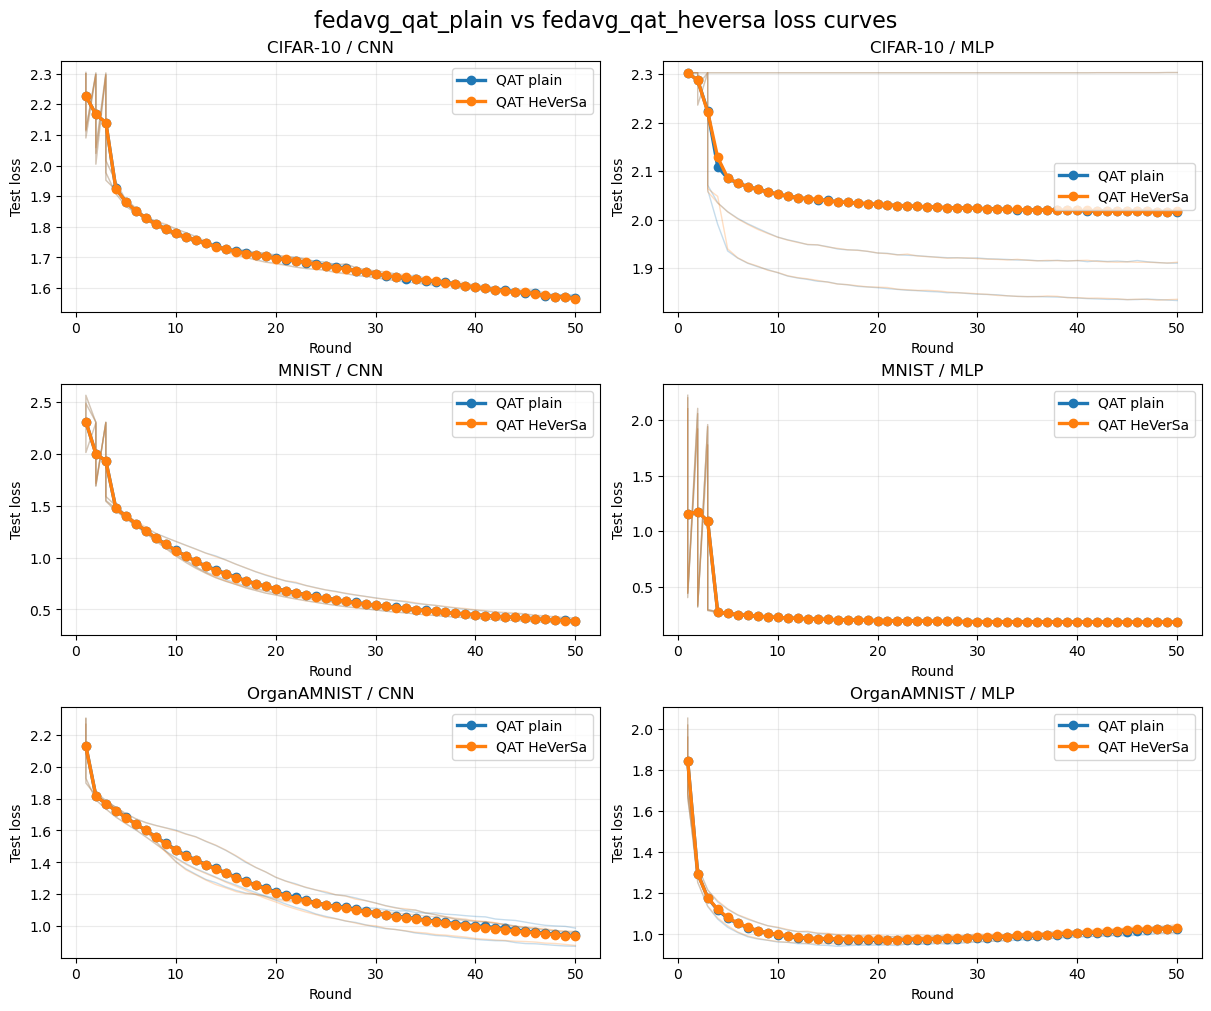

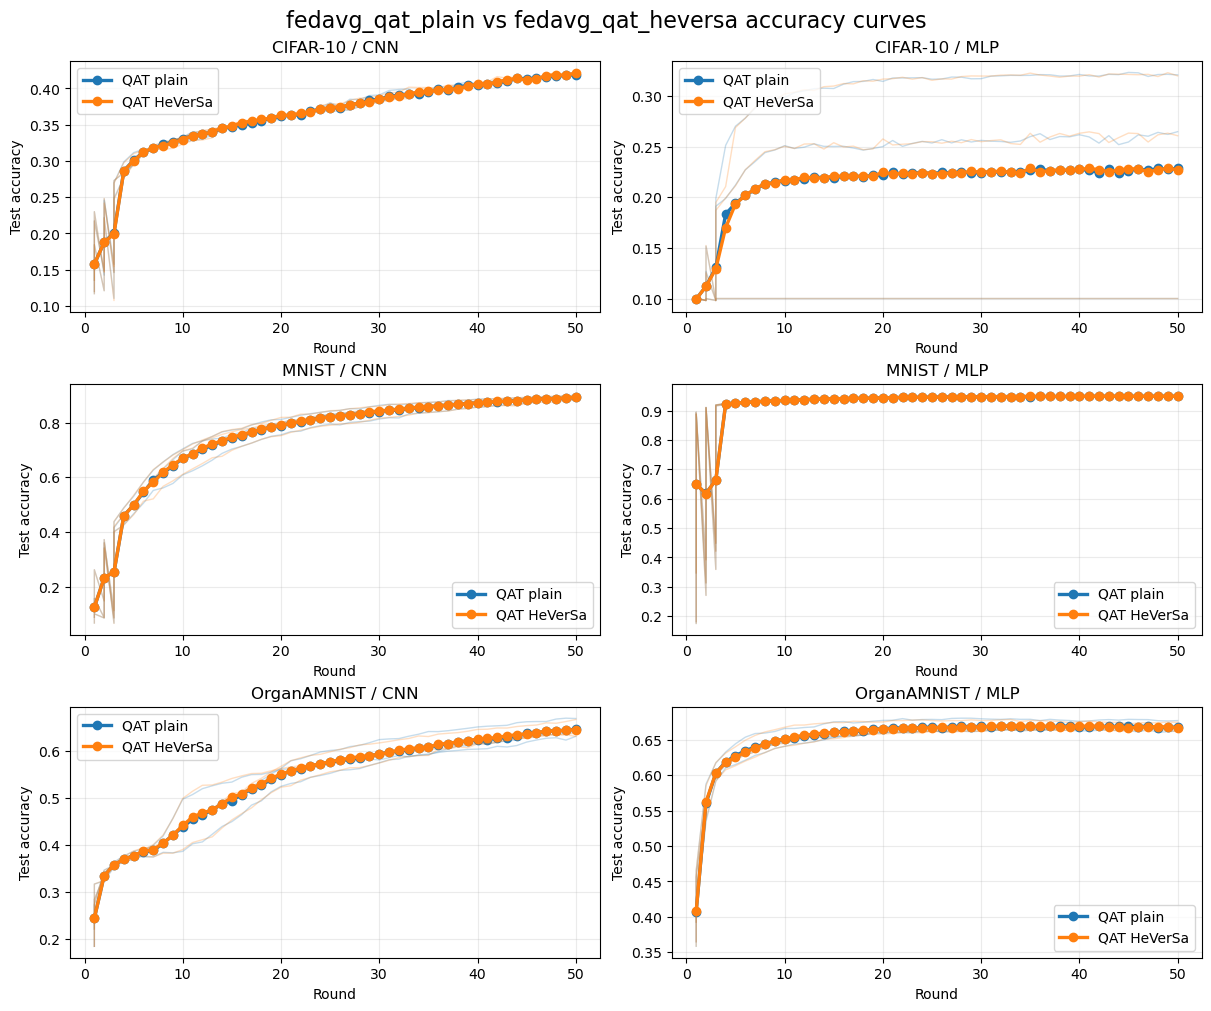

In [8]:
def rows_for(records, dataset=None, network=None, series=None, rep=None):
    rows = records
    if dataset is not None:
        rows = [row for row in rows if row["dataset"] == dataset]
    if network is not None:
        rows = [row for row in rows if row["network"] == network]
    if series is not None:
        rows = [row for row in rows if row["series"] == series]
    if rep is not None:
        rows = [row for row in rows if row["rep"] == rep]
    return rows


def mean_metric_by_round(rows, metric):
    values_by_round = defaultdict(list)
    for row in rows:
        values_by_round[row["round"]].append(row[metric])
    return [
        (round_idx, statistics.mean(values))
        for round_idx, values in sorted(values_by_round.items())
    ]


def plot_metric_grid(records, metric, y_label, title):
    fig, axes = plt.subplots(
        nrows=len(DATASETS),
        ncols=len(NETWORKS),
        figsize=(12, 10),
        sharex=False,
        sharey=False,
        constrained_layout=True,
    )

    for row_idx, dataset in enumerate(DATASETS):
        for col_idx, network in enumerate(NETWORKS):
            ax = axes[row_idx, col_idx]
            subset = rows_for(records, dataset=dataset, network=network)

            for series in SERIES_ORDER:
                series_rows = rows_for(subset, series=series)
                if not series_rows:
                    continue

                rows_by_rep = defaultdict(list)
                for row in series_rows:
                    rows_by_rep[row["rep"]].append(row)

                for rep, rep_rows in rows_by_rep.items():
                    rep_rows = sorted(rep_rows, key=lambda row: row["round"])
                    ax.plot(
                        [row["round"] for row in rep_rows],
                        [row[metric] for row in rep_rows],
                        color=COLORS[series],
                        alpha=0.25,
                        linewidth=1.0,
                    )

                mean_rows = mean_metric_by_round(series_rows, metric)
                ax.plot(
                    [round_idx for round_idx, _ in mean_rows],
                    [value for _, value in mean_rows],
                    marker="o",
                    linewidth=2.4,
                    color=COLORS[series],
                    label=series,
                )

            missing = [series for series in SERIES_ORDER if not rows_for(subset, series=series)]
            if missing:
                ax.text(
                    0.5,
                    0.5,
                    "Missing: " + ", ".join(missing),
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    color="0.35",
                )

            ax.set_title(f"{DISPLAY_NAMES[dataset]} / {network.upper()}")
            ax.set_xlabel("Round")
            ax.set_ylabel(y_label)
            ax.grid(True, alpha=0.25)
            ax.legend(loc="best")

    fig.suptitle(title, fontsize=16)
    return fig


if not records:
    raise ValueError("No usable QAT result rows were loaded. Check RESULTS_DIR and FILE_PREFIX.")

plot_metric_grid(
    records,
    metric="test_loss",
    y_label="Test loss",
    title="fedavg_qat_plain vs fedavg_qat_heversa loss curves",
)
plt.show()

plot_metric_grid(
    records,
    metric="test_accuracy",
    y_label="Test accuracy",
    title="fedavg_qat_plain vs fedavg_qat_heversa accuracy curves",
)
plt.show()

## Optional: Final Metric Table

In [9]:
latest_by_run = {}
for row in records:
    key = (row["dataset"], row["network"], row["series"], row["rep"])
    if key not in latest_by_run or row["round"] > latest_by_run[key]["round"]:
        latest_by_run[key] = row

summary_rows = defaultdict(list)
for row in latest_by_run.values():
    key = (row["dataset"], row["network"], row["series"])
    summary_rows[key].append(row)

header = (
    "dataset", "network", "series", "reps", "final_round",
    "loss_mean", "loss_std", "accuracy_mean", "accuracy_std"
)
print("{:<12s} {:<7s} {:<12s} {:>4s} {:>11s} {:>11s} {:>10s} {:>13s} {:>12s}".format(*header))

for dataset, network, series in sorted(summary_rows):
    rows = summary_rows[(dataset, network, series)]
    losses = [row["test_loss"] for row in rows]
    accuracies = [row["test_accuracy"] for row in rows]
    loss_std = statistics.stdev(losses) if len(losses) > 1 else float("nan")
    accuracy_std = statistics.stdev(accuracies) if len(accuracies) > 1 else float("nan")
    print(
        f"{dataset:<12s} {network:<7s} {series:<12s} {len(rows):>4d} "
        f"{max(row['round'] for row in rows):>11d} "
        f"{statistics.mean(losses):>11.6f} {loss_std:>10.6f} "
        f"{statistics.mean(accuracies):>13.6f} {accuracy_std:>12.6f}"
    )

dataset      network series       reps final_round   loss_mean   loss_std accuracy_mean accuracy_std
cifar10      cnn     QAT HeVerSa     3          50    1.563970   0.005458      0.421467     0.000503
cifar10      cnn     QAT plain       3          50    1.568141   0.009723      0.419100     0.002193
cifar10      mlp     QAT HeVerSa     3          50    2.016868   0.250788      0.226833     0.113746
cifar10      mlp     QAT plain       3          50    2.015386   0.252101      0.228500     0.114765
mnist        cnn     QAT HeVerSa     3          50    0.388422   0.026544      0.892000     0.008508
mnist        cnn     QAT plain       3          50    0.389911   0.023739      0.891567     0.008517
mnist        mlp     QAT HeVerSa     3          50    0.178631   0.011843      0.948767     0.003109
mnist        mlp     QAT plain       3          50    0.178262   0.011880      0.948567     0.003204
organamnist  cnn     QAT HeVerSa     3          50    0.936212   0.049188      0.646173    